# Test 1, Part B: Volume, ticket profile, and two operations claims

Part A assessed concepts. Part B assesses whether you can apply them without step-by-step direction: choose a representation, find the main structure in a small operational dataset, then test two claims about that structure and say what the data can and cannot support.

This part is worth 23 points. It opens on publication, Wednesday, September 23, and is due Monday, September 28 at 11:59 p.m. Central for all students. Work individually. Submit one `.ipynb` notebook, as for homework.

**Resources.** Open book, open notes, open documentation. You may use LLM assistance for understanding and debugging under the homework policy: the explanations you submit must be your own, you must be able to explain the work, and you must disclose material assistance at the end.

**Grading rule.** The interpretation prompts must use the numbers your notebook prints. Generic answers that could describe any dataset, and answers whose numbers do not match your outputs, receive no credit. Code earns credit only through the decisions it shows: the representation, the number of components, the statistic, and the null model. Code that runs earns nothing on its own.

**Time.** Designed for about two hours of focused work. No method here is new to the course, and the setup supplies helpers for display and grouping. Parts 3 and 4 carry 12 of the 23 points, so budget your time for them. If you are well past three hours, stop, write down what you have, and submit.

## The case

Rolling Kitchen operates six food trucks in one city. Each truck serves a lunch window and a dinner window on working days. The operations lead has two beliefs about the August 2026 service windows and wants to know whether the recorded data support them:

1. **Dinner windows run at higher volume than lunch windows.** Based on last summer's peak weeks, the lead currently staffs dinner windows for about 40 percent more orders than lunch windows.
2. **Trucks in the north district run at higher volume than trucks in the south district.**

"Volume" is not a single column. Part of your task is to decide how the seven recorded measurements represent it.

**Provenance.** The file covers the six trucks over the twenty working days from August 3 through August 28, 2026, one row per truck per day per window. Nine windows with a recorded point-of-sale outage were removed before the file was prepared. The operator assigned trucks to districts; the documentation does not say how or whether trucks ever move between districts. There is no information about weather, events, menu changes, or staffing.

| Column | Description | Units |
| --- | --- | --- |
| `window_id` | Row label | - |
| `truck` | Truck identifier, T1 to T6 | - |
| `district` | Operating district, `north` or `south` | - |
| `date` | Service date | ISO date |
| `window` | `lunch` or `dinner` | - |
| `orders` | Orders completed in the window | count |
| `items` | Items sold | count |
| `revenue_usd` | Window revenue | US dollars |
| `avg_ticket_usd` | Average order value | US dollars |
| `queue_peak` | Longest observed queue | customers |
| `prep_minutes` | Average preparation time per order | minutes |
| `card_share` | Share of orders paid by card | proportion |

## Setup

The setup loads the file, prints a summary, and defines three helpers you may use anywhere below. Read the summary, but do not spend time on further exploration; the assessed work starts at Part 1.

In [19]:
from pathlib import Path

%pip install scikit-learn

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy import stats
from sklearn.decomposition import PCA

DATA_URL = (
    "https://raw.githubusercontent.com/olearydj/INSY7130/"
    "main/tests/test1/data/service-windows.csv"
)
data_candidates = [
    Path("data/service-windows.csv"),
    Path("content/tests/test1/data/service-windows.csv"),
]
data_source = next((path for path in data_candidates if path.is_file()), DATA_URL)
FEATURES = [
    "orders", "items", "revenue_usd", "avg_ticket_usd",
    "queue_peak", "prep_minutes", "card_share",
]
windows = pd.read_csv(data_source).set_index("window_id")
measurements = windows[FEATURES]

print("Rows and columns:", windows.shape)
print(windows["window"].value_counts().to_dict(), windows["district"].value_counts().to_dict())
display(measurements.describe().round(2))
display(measurements.corr().round(2))


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Rows and columns: (231, 11)
{'lunch': 117, 'dinner': 114} {'south': 117, 'north': 114}


,orders,items,revenue_usd,avg_ticket_usd,queue_peak,prep_minutes,card_share
count,231.00,231.00,231.00,231.00,231.00,231.00,231.00
mean,60.03,103.85,733.25,12.30,5.52,4.89,0.64
std,17.81,30.94,247.00,2.41,3.37,1.17,0.08
min,12.00,13.00,116.08,6.57,0.00,2.13,0.44
25%,48.00,83.00,552.78,10.68,3.00,4.03,0.58
50%,61.00,105.00,738.91,12.18,5.00,4.83,0.64
75%,73.00,127.00,888.01,13.93,8.00,5.69,0.69
max,105.00,179.00,1444.17,19.38,14.00,8.59,0.88


,orders,items,revenue_usd,avg_ticket_usd,queue_peak,prep_minutes,card_share
orders,1.00,0.94,0.79,-0.17,0.87,-0.36,-0.13
items,0.94,1.00,0.86,0.04,0.82,-0.18,0.03
revenue_usd,0.79,0.86,1.00,0.43,0.68,0.16,0.32
avg_ticket_usd,-0.17,0.04,0.43,1.00,-0.15,0.84,0.73
queue_peak,0.87,0.82,0.68,-0.15,1.00,-0.33,-0.16
prep_minutes,-0.36,-0.18,0.16,0.84,-0.33,1.00,0.70
card_share,-0.13,0.03,0.32,0.73,-0.16,0.70,1.00


The helpers below are supplied so that display and grouping do not cost you time. They contain no decisions.

In [20]:
def summarize_pca(fitted, feature_names):
    """Return (loadings, variance_summary) tables for a fitted PCA."""
    names = [f"PC{i + 1}" for i in range(fitted.n_components_)]
    loadings = pd.DataFrame(fitted.components_.T, index=feature_names, columns=names)
    variance_summary = pd.DataFrame(
        {
            "Eigenvalue (component variance)": fitted.explained_variance_,
            "Variance retained (%)": 100 * fitted.explained_variance_ratio_,
            "Cumulative retained (%)": 100 * fitted.explained_variance_ratio_.cumsum(),
        },
        index=names,
    )
    return loadings, variance_summary


def plot_scores(scores, labels, x="PC1", y="PC2", xlabel=None, ylabel=None):
    """Scatter two score columns, marking each row by a label Series (for example windows["window"])."""
    fig, ax = plt.subplots(figsize=(6, 4.5))
    for value, marker in zip(sorted(labels.unique()), ("o", "^", "s", "D")):
        mask = labels == value
        ax.scatter(scores.loc[mask, x], scores.loc[mask, y], marker=marker, alpha=0.7, label=str(value))
    ax.axvline(0, color="gray", lw=0.5)
    ax.axhline(0, color="gray", lw=0.5)
    ax.set_xlabel(xlabel or x)
    ax.set_ylabel(ylabel or y)
    ax.legend(title=labels.name)
    plt.tight_layout()
    plt.show()


def split_groups(values, labels, first, second):
    """Return (first_array, second_array): the values whose label equals first, then second."""
    return values[labels == first].to_numpy(), values[labels == second].to_numpy()

## Part 1: Represent volume (5 points)

Decide how to represent the seven measurements before reducing them, fit PCA, and identify what its leading components measure. The decisions are yours; the mechanics are not new.

Your work must show:

- **1a.** Whether you standardize the columns, with evidence for the decision. Fit PCA to `measurements` and to a standardized copy, call `summarize_pca` on each, and compare the two PC1 loadings.
- **1b.** Your choice of how many components to keep, with the reason, using the variance summary from your chosen representation.
- **1c.** The loadings of the first two components and a one-line operational name for each, in Rolling Kitchen's terms.
- **1d.** One figure that shows the structure you found. `plot_scores(scores, windows["window"])` is one acceptable choice.

Save the component scores in a DataFrame named `scores` with columns `PC1`, `PC2`, and so on, indexed by `window_id`, and orient PC1 so that a larger score means more volume: if the `orders` loading on PC1 is negative, negate that column of `scores`. Later parts use it.

In [21]:
# 1a. Standardize, fit PCA to both frames, and compare the PC1 loadings.
# PCA on the original measurements
pca_raw = PCA()
pca_raw.fit(measurements)

raw_loadings, raw_variance = summarize_pca(pca_raw, FEATURES)

# Standardize each measurement to mean 0 and standard deviation 1
measurements_std = (measurements - measurements.mean()) / measurements.std(ddof=0)

# PCA on standardized measurements
pca_std = PCA()
pca_std.fit(measurements_std)

std_loadings, std_variance = summarize_pca(pca_std, FEATURES)

# Compare PC1 loadings
comparison = pd.DataFrame({
    "Raw PC1": raw_loadings["PC1"],
    "Standardized PC1": std_loadings["PC1"]
})

display(comparison.round(3))
display(measurements.std().rename("Standard deviation").round(2))

,Raw PC1,Standardized PC1
orders,0.057,0.523
items,0.107,0.508
revenue_usd,0.993,0.432
avg_ticket_usd,0.004,-0.063
queue_peak,0.009,0.488
prep_minutes,0.001,-0.187
card_share,0.000,-0.066


orders             17.81
items              30.94
revenue_usd       247.00
avg_ticket_usd      2.41
queue_peak          3.37
prep_minutes        1.17
card_share          0.08
Name: Standard deviation, dtype: float64

In [22]:
display(std_variance.round(2))

,Eigenvalue (component variance),Variance retained (%),Cumulative retained (%)
PC1,3.56,50.65,50.65
PC2,2.72,38.70,89.35
PC3,0.33,4.69,94.04
PC4,0.20,2.91,96.96
PC5,0.14,2.02,98.98
PC6,0.05,0.78,99.76
PC7,0.02,0.24,100.00


Retained variance:


,Eigenvalue (component variance),Variance retained (%),Cumulative retained (%)
PC1,3.561,50.648,50.648
PC2,2.721,38.704,89.352


Loadings:


,PC1,PC2
orders,0.523,-0.017
items,0.508,0.104
revenue_usd,0.432,0.324
avg_ticket_usd,-0.063,0.574
queue_peak,0.488,-0.030
prep_minutes,-0.187,0.525
card_share,-0.066,0.527


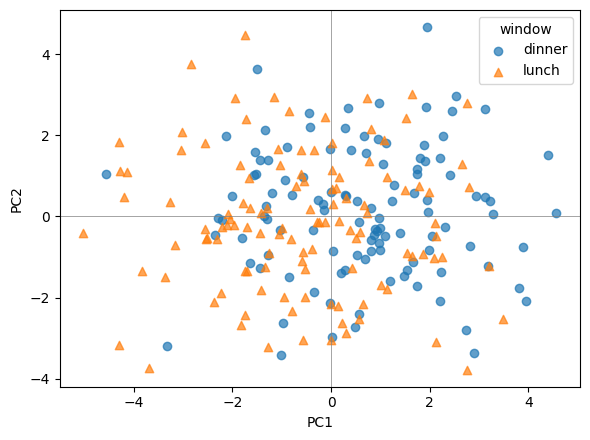

In [23]:
# 1b-1d. Retained variance and your k, the first two loadings, the oriented scores, and the figure.
# 1b. Retain two components
k = 2

pca = PCA(n_components=k)
pca.fit(measurements_std)

loadings, variance_summary = summarize_pca(pca, FEATURES)

print("Retained variance:")
display(variance_summary.round(3))

# 1c. First two component loadings
print("Loadings:")
display(loadings.round(3))

# 1d. Component scores, indexed by window_id
scores = pd.DataFrame(
    pca.transform(measurements_std),
    index=measurements.index,
    columns=["PC1", "PC2"]
)

# Orient PC1 so larger scores mean greater volume
if loadings.loc["orders", "PC1"] < 0:
    scores["PC1"] = -scores["PC1"]
    loadings["PC1"] = -loadings["PC1"]

# Plot the structure by lunch/dinner window
plot_scores(
    scores,
    windows["window"],
    x="PC1",
    y="PC2",
    xlabel="PC1",
    ylabel="PC2"
)

## Part 2: Test the two claims (6 points)

Use your volume score to test each of the operations lead's claims. `split_groups(values, labels, first, second)` returns the two arrays that a two-sample SciPy call expects.

Your work must show:

- **2a.** A one-number statistic that represents a claim, written as a two-argument function and stated before any test is run, with its sign convention. A signed difference of group means is acceptable; another statistic is acceptable if you say why it represents the claim better.
- **2b.** The null model in one sentence for each claim: what is being shuffled, and what that assumes.
- **2c.** Three SciPy permutation tests, each with 5,000 resamples, a two-sided alternative, and random seed 7130, printing the observed statistic and the simulated p-value for each: claim 1 on your volume score (dinner minus lunch), claim 2 on your volume score (north minus south), and claim 2 on `revenue_usd`. Write a small function or repeat the call, whichever you prefer. Revenue is the figure the operations lead sees in the monthly summary, so the two claim-2 results are what you will reconcile in Part 3.
- **2d.** Two 95 percent bootstrap intervals (5,000 resamples, seed 7130, percentile method), printed: the percent difference in mean `orders`, dinner relative to lunch, which is the quantity behind the lead's staffing figure; and the difference in mean `revenue_usd`, north minus south.

In [24]:
# 2a-2c. Statistic function and the three permutation results. State each null model in a comment or a short markdown cell.
# 2a. Define the statistic function for permutation tests
def mean_difference(x, y):
    return np.mean(x) - np.mean(y)

**2b. Null model claims**   
- Claim 1 null model: Shuffle the lunch/dinner labels among the PC1 volume scores, assuming that under the null hypothesis the volume scores are exchangeable between lunch and dinner windows.   
- Claim 2 null model: Shuffle the north/south district labels among the outcome values, assuming that under the null hypothesis the values are exchangeable between north and south districts. The same district-label null model is used for both PC1 volume and revenue.

In [25]:
# Create groups for Claim 1: dinner minus lunch, using PC1 volume
dinner_volume, lunch_volume = split_groups(
scores["PC1"],
windows["window"],
"dinner",
"lunch"
)

# Create groups for Claim 2: north minus south, using PC1 volume
north_volume, south_volume = split_groups(
scores["PC1"],
windows["district"],
"north",
"south"
)

# Create groups for Claim 2: north minus south, using revenue
north_revenue, south_revenue = split_groups(
windows["revenue_usd"],
windows["district"],
"north",
"south"
)


# Helper for the required permutation tests
def run_permutation_test(x, y, label):
    result = stats.permutation_test(
        (x, y),
        mean_difference,
        permutation_type="independent",
        alternative="two-sided",
        n_resamples=5000,
        random_state=7130
    )

    print(label)
    print(f"Observed statistic: {result.statistic:.4f}")
    print(f"Simulated p-value: {result.pvalue:.4f}")
    print()

In [26]:
# 2c. Three required permutation tests

run_permutation_test(
dinner_volume,
lunch_volume,
"Claim 1: PC1 volume, dinner minus lunch"
)

run_permutation_test(
north_volume,
south_volume,
"Claim 2: PC1 volume, north minus south"
)

run_permutation_test(
north_revenue,
south_revenue,
"Claim 2: revenue_usd, north minus south"
)

Claim 1: PC1 volume, dinner minus lunch
Observed statistic: 1.2465
Simulated p-value: 0.0004

Claim 2: PC1 volume, north minus south
Observed statistic: -0.8475
Simulated p-value: 0.0004

Claim 2: revenue_usd, north minus south
Observed statistic: 24.1370
Simulated p-value: 0.4647



In [27]:
# 2d. Bootstrap intervals: percent difference in orders (dinner relative to lunch) and revenue difference (north minus south).

# Percent difference in the first group's mean relative to the second:
# 100 * (mean(first) - mean(second)) / mean(second)
def percent_difference(x, y):
    return 100 * (np.mean(x) - np.mean(y)) / np.mean(y)

dinner_orders, lunch_orders = split_groups(
windows["orders"],
windows["window"],
"dinner",
"lunch"
)

orders_boot = stats.bootstrap(
    (dinner_orders, lunch_orders),
    percent_difference,
    n_resamples=5000,
    confidence_level=0.95,
    method="percentile",
    random_state=7130,
    vectorized=False
)

orders_observed = percent_difference(
    dinner_orders,
    lunch_orders
)

print("Dinner relative to lunch: percent difference in mean orders")
print(f"Observed percent difference: {orders_observed:.2f}%")
print(
    f"95% bootstrap interval: "
    f"({orders_boot.confidence_interval.low:.2f}%, "
    f"{orders_boot.confidence_interval.high:.2f}%)"
)

revenue_boot = stats.bootstrap(
    (north_revenue, south_revenue),
    mean_difference,
    n_resamples=5000,
    confidence_level=0.95,
    method="percentile",
    random_state=7130,
    vectorized=False
)

revenue_observed = mean_difference(
    north_revenue,
    south_revenue
)

print()
print("North minus south: difference in mean revenue_usd")
print(f"Observed revenue difference: ${revenue_observed:.2f}")
print(
    f"95% bootstrap interval: "
    f"(${revenue_boot.confidence_interval.low:.2f}, "
    f"${revenue_boot.confidence_interval.high:.2f})"
)

Dinner relative to lunch: percent difference in mean orders
Observed percent difference: 20.33%
95% bootstrap interval: (11.85%, 29.55%)

North minus south: difference in mean revenue_usd
Observed revenue difference: $24.14
95% bootstrap interval: ($-40.21, $88.09)


## Part 3: Interpretation (9 points)

Answer each prompt in a short paragraph using the numbers your notebook printed.

**3a. Representation (3 points).** State the first-component loadings from your chosen representation and what PC1 measures. State the retained variance at your chosen number of components. Then say what PC1 measured when the columns were not standardized, and why that would have been the wrong representation of volume.

>  PC1 had loadings of 0.523 for orders, 0.508 for items, 0.432 for revenue, -0.063 for average ticket, 0.488 for peak queue, -0.187 for prep time, and -0.066 for card share, so I interpret PC1 as overall service-window volume because orders, items, revenue, and peak queue have relatively large positive loadings. I retained two components, which explained **89.35%** of total variance (50.65% PC1 and 38.70% PC2); their eigenvalues were 3.56 and 2.72, compared with 0.33 for PC3. Without standardization, PC1 was *almost entirely revenue*, with a loading of 0.993, compared with 0.057 for orders and 0.107 for items. That would be a poor representation of overall volume because revenue had a much larger numerical standard deviation (247.00), causing raw PCA to reflect measurement scale rather than the shared operational volume structure.

**3b. Claim 1 (3 points).** Report the observed volume statistic with its direction and the simulated p-value under your null model. Then report the interval for the percent difference in orders and say whether the 40 percent staffing figure is consistent with it. Give one bounded conclusion the evidence supports and one conclusion it does not support. Do not describe the p-value as the probability that the claim is false.

> The observed difference in mean volume score, dinner minus lunch, was 1.2465 PC1 units, so **dinner windows had higher average overall volume than lunch windows**. The simulated two-sided permutation *p-value* was **0.0004**, providing **strong evidence of a lunch-dinner difference under the null model of exchangeable window labels**. Mean orders were **20.33%** *higher at dinner*, with a 95% bootstrap interval of 11.85% to 29.55%. Because 40% is outside this interval, the lead's current 40% additional staffing figure is not consistent with the August difference in mean orders. The data support the bounded conclusion that recorded **dinner windows in August 2026 had higher volume than recorded lunch windows**, *but* they **do not support** the conclusion that dinner required 40% more orders-based staffing, nor do these observational data establish that the dinner window itself *caused* the higher volume.

**3c. Claim 2 (3 points).** Report the observed statistic and simulated p-value for your volume score and for revenue. Tell the operations lead, in plain language, what the volume result establishes about the belief and why the revenue result differs. Then use the revenue interval to state the range of revenue differences the data are consistent with, and explain why the revenue result's "no evidence of a difference" is not the same as "no difference."

> For overall volume, the observed north-minus-south difference was -0.8475 PC1 units, with a simulated two-sided *p-value* of **0.0004**. Because higher PC1 means greater volume, the negative statistic provides **strong evidence that the recorded south district windows had higher average overall volume than north district windows**, which is the opposite of the operations lead's belief. For revenue alone, however, the observed north-minus-south difference was +$24.14, with a *p-value* of **0.4647**, so the **revenue data do not provide evidence of a district difference**. These results can differ because PC1 represents overall volume using several measurements, with substantial loadings from orders, items, queue peak, and revenue, while revenue is only one measurement. The 95% bootstrap interval for north-minus-south mean revenue was -$40.21 to +$88.09 per window, so the data are consistent with differences ranging from moderately higher south revenue to higher north revenue. Therefore, "no evidence of a revenue difference" does not mean the districts have equal revenue; it means the observed data do not determine the direction or magnitude of the revenue difference precisely enough to establish one.

## Part 4: Bounded claim, reproducibility, and disclosure (3 points)

**4a.** In two or three sentences, state the scope of what this analysis can claim about Rolling Kitchen's operations. Name what the file covers, what was removed, and one thing the provenance leaves unknown that limits the claim.

> This analysis supports conclusions about the recorded lunch and dinner service windows for Rolling Kitchen's six trucks during the twenty working days from August 3 through August 28, 2026. Nine windows with recorded point-of-sale outages were removed, and the results should not be generalized beyond these recorded windows because potentially relevant factors are unknown, including weather, events, menu changes, and staffing conditions.

Restart the runtime and run all cells in order before submitting. Keep the outputs and check that the numbers in your answers match them.

| Evaluation | Points |
| --- | ---: |
| Part 1: representation decision, k, component naming, figure | 5 |
| Part 2: statistic, null models, three permutation results, two intervals | 6 |
| Part 3: interpretation tied to your outputs | 9 |
| Part 4: bounded claim, reproducibility, and assistance disclosure | 3 |
| **Total** | **23** |

**Assistance disclosure:** Identify material assistance, including any LLM use, and how you checked it. Write `None` if you received no material assistance.

> I used Microsoft Copilot to help interpret the assignment requirements, debug Python code, and check my reasoning and statistical interpretations. I verified the assistance by running the analysis myself, checking that the reported values matched my notebook outputs, and reviewing the PCA, permutation-test, and bootstrap concepts so that I could explain the analysis independently.

**Optional, ungraded feedback:** Approximately how much active time did you spend, excluding breaks? Which part required the most effort, and was anything unclear?

> I think i spent around 3 hours on this assignment. The PCA representation and interpretation required the most effort, especially connecting the component loadings to an operational definition of volume. The distinction between the overall volume result and the revenue-only result for the district comparison also required careful interpretation.